In [1]:
import numpy as np
import gensim.downloader as api
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import precision_score, recall_score, f1_score

In [2]:
model = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


In [7]:
def get_sentence_vector(sentence):
    words = [word for word in sentence.lower().split() if word in model]
    if not words:
        return np.zeros(model.vector_size)
    return np.mean([model[word] for word in words], axis = 0)   
#this is calculating the word embedding from the sentence itself
#now we are using this setup for the nlp tasks    

In [9]:
# Segmenting similar tasks

tasks = [ "clean data", "build model", "train algorithm", "remove outliers",
    "deploy model", "visualize data", "tune hyperparameters", "generate report"]

task_vectors = [get_sentence_vector(task) for task in tasks]

kmeans = KMeans(n_clusters = 3, random_state =0)
labels = kmeans.fit_predict(task_vectors)

for i,label in enumerate(labels):
    print(f"Cluster{label}:{tasks[i]}")

Cluster1:clean data
Cluster0:build model
Cluster0:train algorithm
Cluster1:remove outliers
Cluster0:deploy model
Cluster1:visualize data
Cluster2:tune hyperparameters
Cluster1:generate report


In [13]:
# Checking accuracy in summary

def check_summary_accuracy(original_text,summary_text):
    orig_words = [word for word in original_text.lower().split() if word in model]
    summary_words = [word for word in summary_text.lower().split() if word in model]

    orig_vecs = np.array([model[word] for word in orig_words])
    summary_vecs = np.array([model[word] for word in summary_words])
    
    similarities = cosine_similarity(summary_vecs,orig_vecs)
    coverage = np.mean(np.max(similarities, axis = 1))
    return coverage

In [14]:
original = "The quick brown fox jumps over the lazy dog and runs into the forest."
summary = "A brown fox jumps over a lazy dog."

accuracy_score = check_summary_accuracy(original, summary)
print("Summary accuracy score (cosine-based):", accuracy_score)

Summary accuracy score (cosine-based): 0.93599373


In [15]:
#Text Clustering

documents = [
    "Dogs are wonderful pets",
    "Cats are independent animals",
    "Dogs love to play fetch",
    "Cats love to nap",
    "Football is a great sport",
    "Soccer is popular worldwide",
]

doc_vec = [get_sentence_vector(doc) for doc in documents]
kmeans = KMeans(n_clusters =2, random_state = 42)
cluster= kmeans.fit_predict(doc_vec)

for i, label in enumerate(cluster):
    print(f"Cluster {label}: {documents[i]}")

Cluster 0: Dogs are wonderful pets
Cluster 0: Cats are independent animals
Cluster 0: Dogs love to play fetch
Cluster 0: Cats love to nap
Cluster 1: Football is a great sport
Cluster 1: Soccer is popular worldwide


In [19]:
# Semantic Search
corpus = [
    "How to train a neural network",
    "Ways to clean data for machine learning",
    "Data visualization techniques",
    "Best practices for model deployment",
]

query = "visualizing data"
query_vec = get_sentence_vector(query)

corpus_vecs = [get_sentence_vector(doc) for doc in corpus]
sims = cosine_similarity([query_vec], corpus_vecs)[0]

results = sorted(zip(corpus, sims), key=lambda x: x[1], reverse=True) 
print("Semantic Search Results:")
for doc, score in results:
    print(f"{score:.3f}: {doc}") # {score:.3f} → formats score to 3 decimal places

Semantic Search Results:
0.829: Data visualization techniques
0.634: Ways to clean data for machine learning
0.515: How to train a neural network
0.438: Best practices for model deployment


In [2]:
# Part 1: Build Co-occurrence Matrix
import numpy as np 
from collections import defaultdict
import itertools
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder 
from sklearn.decomposition  import PCA
import re

In [3]:
# Define a larger corpus
corpus = [
    "Natural language processing enables computers to understand human language.",
    "Machine learning is a part of artificial intelligence.",
    "Deep learning is a subfield of machine learning.",
    "Text data can be used for sentiment analysis.",
    "Named entity recognition is an information extraction technique.",
    "GloVe stands for Global Vectors for Word Representation.",
    "It captures semantic relationships between words.",
    "Word embeddings are useful for NLP applications.",
    "This tutorial implements GloVe from scratch.",
    "Sentiment analysis determines if a sentence is positive or negative."
]

In [8]:
#clean and tokenize
def preprocess(sentence):
    return re.sub(r"[^a-zA-Z ]", "" ,sentence).lower().split() # this will replace non-character.

tokenized = [preprocess(sentence) for sentence in corpus]    

In [12]:
tokenized[:1]

[['natural',
  'language',
  'processing',
  'enables',
  'computers',
  'to',
  'understand',
  'human',
  'language']]

In [25]:
# Build Vocabulary

vocab = sorted(set(itertools.chain(*tokenized)))
vocab_length = len(vocab)
word2id = {word:i for i, word in enumerate(vocab)}
id2word = {i: word for word,i in word2id.items()}

print(id2word)

{0: 'a', 1: 'an', 2: 'analysis', 3: 'applications', 4: 'are', 5: 'artificial', 6: 'be', 7: 'between', 8: 'can', 9: 'captures', 10: 'computers', 11: 'data', 12: 'deep', 13: 'determines', 14: 'embeddings', 15: 'enables', 16: 'entity', 17: 'extraction', 18: 'for', 19: 'from', 20: 'global', 21: 'glove', 22: 'human', 23: 'if', 24: 'implements', 25: 'information', 26: 'intelligence', 27: 'is', 28: 'it', 29: 'language', 30: 'learning', 31: 'machine', 32: 'named', 33: 'natural', 34: 'negative', 35: 'nlp', 36: 'of', 37: 'or', 38: 'part', 39: 'positive', 40: 'processing', 41: 'recognition', 42: 'relationships', 43: 'representation', 44: 'scratch', 45: 'semantic', 46: 'sentence', 47: 'sentiment', 48: 'stands', 49: 'subfield', 50: 'technique', 51: 'text', 52: 'this', 53: 'to', 54: 'tutorial', 55: 'understand', 56: 'used', 57: 'useful', 58: 'vectors', 59: 'word', 60: 'words'}


In [41]:
#build a co-occurence matrix
def build_cooccurence_matrix(tokenized_corpus, vocab_size, word2id, window_size=2):
    cooccurence_matrix = np.zeros((vocab_size,vocab_size), dtype = np.float64)
    
    for sentence in tokenized_corpus:
        sentence_ids = [word2id[word] for word in sentence]
        for idx, word_id in enumerate(sentence_ids):
            start = max(idx-window_size,0)
            end = min(idx+window_size+1,len(sentence_ids))
            for context_idx in range(start,end):
                if context_idx != idx:
                    context_id = sentence_ids[context_idx]
                    cooccurence_matrix[word_id, context_id] += 1
    return cooccurence_matrix

X = build_cooccurence_matrix(tokenized, vocab_length, word2id, window_size=2)
print("Co-occurrence Matrix shape:", X.shape)    

Co-occurrence Matrix shape: (61, 61)


In [43]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(61, 61))

In [44]:
#Part 2: Initialize GloVe Parameters

In [1]:
# for now leaving the co-occurence matrix

Word2Vec

In [1]:
from gensim.models import Word2Vec

In [4]:
corpus = [
    "The quick brown fox jumps over the lazy dog",
    "I love learning natural language processing",
    "FastText uses character n-grams to improve embedding quality",
    "Word embeddings help in many NLP tasks",
    "Dogs are better than cats for some people",
    "I enjoy solving problems with machine learning"
]

In [6]:
tokenized = [sentence.lower().split() for sentence in corpus]

In [7]:
model = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=1, sg=1, negative=10, epochs=100)

In [9]:
word = "quick"
print(f"Embeding for {word}", model.wv[word][:10])

Embeding for quick [-5.8494546e-03  1.0523463e-02 -2.2868225e-03 -8.3045689e-03
  7.3283426e-03 -5.1442878e-03 -7.5801625e-05  3.8610005e-03
  1.3758815e-03 -9.6925339e-03]


In [10]:
#similar word as "quick"
model.wv.most_similar("quick", topn = 5)

[('the', 0.49860459566116333),
 ('to', 0.3880794048309326),
 ('character', 0.38161060214042664),
 ('uses', 0.3693797290325165),
 ('solving', 0.3646586537361145)]

In [11]:
# FastText

In [12]:
from gensim.models import FastText

In [13]:
corpus = [
    "The quick brown fox jumps over the lazy dog",
    "I love learning natural language processing",
    "FastText uses character n-grams to improve embedding quality",
    "Word embeddings help in many NLP tasks",
    "Dogs are better than cats for some people",
    "I enjoy solving problems with machine learning"
]


In [14]:
tokenized = [sentence.lower().split() for sentence in corpus]

In [15]:
#Train FastText in CBOW mode (sg=0)
cbow_model = FastText(sentences = tokenized, vector_size = 100, window = 5,min_count = 1, sg =0, epochs =100)

In [16]:
#checking for the embeddings
word = "learning"
print(f"Embedding for {word}:", cbow_model.wv[word][:10])

Embedding for learning: [ 0.00107453 -0.00015203 -0.00102786  0.00040455 -0.00183379 -0.00054705
 -0.00055685 -0.00074659  0.00147683  0.0002427 ]


In [17]:
cbow_model.wv.most_similar("nl", topn =5)  # here their is no word nl but due to the fasttext it didn't give the error

[('nlp', 0.3305633068084717),
 ('character', 0.2486092746257782),
 ('processing', 0.19566285610198975),
 ('dog', 0.1576220840215683),
 ('enjoy', 0.14283734560012817)]

In [33]:
#NLP Tasks 
# 1- Document Rating

from gensim.models import Word2Vec
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

In [34]:
data = [
    ("I loved the movie, it was fantastic!", "positive", 4.5),
    ("The movie was okay, not the best.", "neutral", 3.0),
    ("Terrible movie. Wouldn’t recommend.", "negative", 1.2),
    ("Really enjoyed the characters and plot.", "positive", 4.7),
    ("It was boring and predictable.", "negative", 2.0),
    ("An average film, not too bad.", "neutral", 3.2)
]

In [35]:
sentences = [text.lower().split() for text, _, _ in data]
scores = [score for _, _,score in data] 

In [39]:
#Convert each sentence into sentence vector (average of word vectors)

def sentence_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis = 0)
    else:
        return np.zeros(model.vector_size)

x =[sentence_vector(tokens,model) for tokens in sentences]
y = scores

reg = Ridge()

reg.fit(x,y)
y_pred = reg.predict(x)
mse = mean_squared_error(y,y_pred)
print(f"MSE on training data: {mse : .3f}")

new_review = "It was a wonderful and heartwarming film"
new_tokens = new_review.lower().split()
new_vec = sentence_vector(new_tokens,model)
predicted_score = reg.predict([new_vec])[0]
print(f"Predicted Score for Review: \"{new_review}\" → {predicted_score:.2f}")

MSE on training data:  1.546
Predicted Score for Review: "It was a wonderful and heartwarming film" → 3.09


In [40]:
# 2- Document Clustering

In [41]:
from gensim.models import Word2Vec
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [42]:
documents = [
    "Absolutely loved this movie! The story was brilliant.",
    "The cinematography and the music were amazing.",
    "It was a boring and predictable movie.",
    "Fantastic performances by the entire cast.",
    "The plot was confusing and slow.",
    "A heartwarming story that touched my soul.",
    "Terrible acting. Couldn't finish watching.",
    "An exciting thriller that kept me on edge.",
    "Not my cup of tea. Very slow pacing.",
    "The direction and screenplay were top-notch.",
    "A masterpiece with great emotional depth.",
    "Very bad movie. Poorly executed.",
    "An inspiring film with powerful messages.",
    "Mediocre at best. I expected more.",
    "Great visuals but the story lacked impact.",
    "Loved the dialogues and the chemistry between leads.",
    "Too many clichés and weak character development.",
    "One of the best films I've seen this year.",
    "The editing was sloppy and disjointed.",
    "A cinematic experience I won’t forget.",
    "Fails to deliver on the hype.",
    "Stellar performances but the plot was underwhelming.",
    "A fun ride with lots of laughs.",
    "Dragged on forever. I lost interest halfway.",
    "Impressive production design and art direction.",
    "Very emotional and beautifully shot.",
    "Just plain bad. Don't waste your time.",
    "It had moments, but overall forgettable.",
    "A gem of a movie. Highly recommended!",
    "Predictable plot twists. Nothing new to offer."
]

In [43]:
#tokenize

token = [doc.lower().split() for doc in documents]

In [45]:
# train word2vec

w2v_model = Word2Vec(token, vector_size = 100, window = 5 ,min_count =1, workers = 2 , epochs =100)

In [52]:
#Convert each document to a vector 
def doc_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors :
        return np.mean(vectors, axis = 0)
    else:
        return np.zeros(model.vector_size)

x = np.array([doc_vector(doc,w2v_model) for doc in token])
kmeans = KMeans(n_clusters =4, random_state = 2)
pred = kmeans.fit_predict(x)

In [55]:
#Print clustered documents
n_clusters =4
print("\n📁 Document Clusters:")
for i in range(n_clusters):
    print(f"\nCluster {i}:")
    for idx,label in enumerate(pred):
        if label == i:
            print(f"{documents[idx]}")


📁 Document Clusters:

Cluster 0:
Fantastic performances by the entire cast.
An exciting thriller that kept me on edge.
Mediocre at best. I expected more.
Too many clichés and weak character development.
A cinematic experience I won’t forget.
Dragged on forever. I lost interest halfway.
Just plain bad. Don't waste your time.
It had moments, but overall forgettable.
Predictable plot twists. Nothing new to offer.

Cluster 1:
Absolutely loved this movie! The story was brilliant.
The cinematography and the music were amazing.
It was a boring and predictable movie.
The plot was confusing and slow.
A heartwarming story that touched my soul.
Not my cup of tea. Very slow pacing.
The direction and screenplay were top-notch.
Great visuals but the story lacked impact.
Loved the dialogues and the chemistry between leads.
One of the best films I've seen this year.
The editing was sloppy and disjointed.
Fails to deliver on the hype.
Stellar performances but the plot was underwhelming.

Cluster 2:
Te

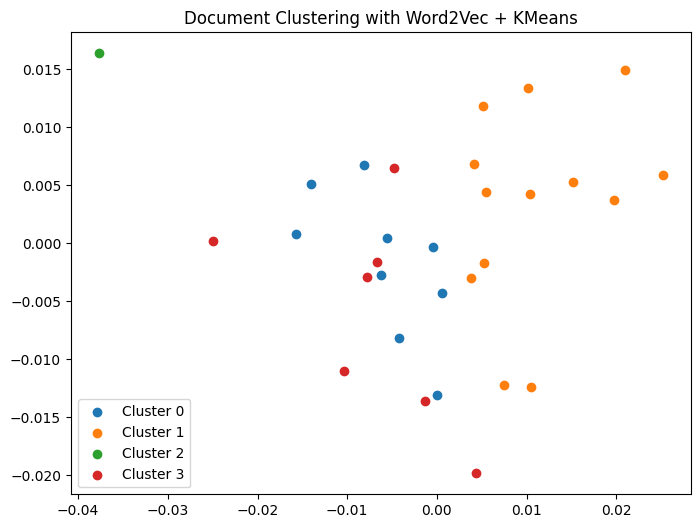

In [56]:
#Optional - Visualize clusters using PCA
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(x)

plt.figure(figsize=(8, 6))
for i in range(n_clusters):
    plt.scatter(X_reduced[pred == i, 0], X_reduced[pred == i, 1], label=f"Cluster {i}")
plt.title("Document Clustering with Word2Vec + KMeans")
plt.legend()
plt.show()

In [57]:
# 3- Text Similarity Search

In [58]:
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

#Same list of movie review-style documents
documents = [
    "Absolutely loved this movie! The story was brilliant.",
    "The cinematography and the music were amazing.",
    "It was a boring and predictable movie.",
    "Fantastic performances by the entire cast.",
    "The plot was confusing and slow.",
    "A heartwarming story that touched my soul.",
    "Terrible acting. Couldn't finish watching.",
    "An exciting thriller that kept me on edge.",
    "Not my cup of tea. Very slow pacing.",
    "The direction and screenplay were top-notch.",
    "A masterpiece with great emotional depth.",
    "Very bad movie. Poorly executed.",
    "An inspiring film with powerful messages.",
    "Mediocre at best. I expected more.",
    "Great visuals but the story lacked impact.",
    "Loved the dialogues and the chemistry between leads.",
    "Too many clichés and weak character development.",
    "One of the best films I've seen this year.",
    "The editing was sloppy and disjointed.",
    "A cinematic experience I won’t forget.",
    "Fails to deliver on the hype.",
    "Stellar performances but the plot was underwhelming.",
    "A fun ride with lots of laughs.",
    "Dragged on forever. I lost interest halfway.",
    "Impressive production design and art direction.",
    "Very emotional and beautifully shot.",
    "Just plain bad. Don't waste your time.",
    "It had moments, but overall forgettable.",
    "A gem of a movie. Highly recommended!",
    "Predictable plot twists. Nothing new to offer."
]

In [60]:
#tokenize

tokenized_docs = [doc.lower().split() for doc in documents]

#train w2v

w2v_model = Word2Vec(tokenized_docs, vector_size=100, window=5, min_count=1, workers=4, epochs=100)

In [61]:
#create document embeddings
def doc_vector(tokens,modle):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors :
        return np.mean(vectors, axis = 0)
    else:
        return np.zeros(model.vector_size)

doc_embeddings  =np.array([doc_vector(doc,w2v_model) for doc in tokenized_docs])        

In [63]:
#Define similarity search

def similar_docs(query,top_k = 5):
    query_token = query.lower().split()
    query_vec = doc_vector(query_token,w2v_model).reshape(1,-1)
    similarities = cosine_similarity(query_vec,doc_embeddings).flatten()
    top= similarities.argsort()[-top_k:][::-1]

    print(f"\n🔍 Query: {query}")
    print("\n📄 Top Similar Documents:")
    for i in top:
        print(f"  - (Score: {similarities[i]:.3f}) {documents[i]}")

similar_docs("emotional story about love and friendship")
similar_docs("thrilling and action packed movie")
similar_docs("confusing and poorly made film")


🔍 Query: emotional story about love and friendship

📄 Top Similar Documents:
  - (Score: 0.414) Too many clichés and weak character development.
  - (Score: 0.330) Stellar performances but the plot was underwhelming.
  - (Score: 0.330) One of the best films I've seen this year.
  - (Score: 0.330) The editing was sloppy and disjointed.
  - (Score: 0.330) Great visuals but the story lacked impact.

🔍 Query: thrilling and action packed movie

📄 Top Similar Documents:
  - (Score: 0.000) Predictable plot twists. Nothing new to offer.
  - (Score: 0.000) A gem of a movie. Highly recommended!
  - (Score: 0.000) It had moments, but overall forgettable.
  - (Score: 0.000) Just plain bad. Don't waste your time.
  - (Score: 0.000) Very emotional and beautifully shot.

🔍 Query: confusing and poorly made film

📄 Top Similar Documents:
  - (Score: 0.000) Predictable plot twists. Nothing new to offer.
  - (Score: 0.000) A gem of a movie. Highly recommended!
  - (Score: 0.000) It had moments, but over

In [1]:
#DOC2VEC

In [11]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

In [12]:
data = [
    "AI is transforming healthcare",
    "Natural language processing is fascinating",
    "Self-driving cars rely on sensors",
    "Chatbots improve customer service",
    "Computer vision powers facial recognition",
    "Robotics is revolutionizing manufacturing"
]


In [13]:
#for now leaving the doc2vec and NLTK & SPACY

In [14]:
#TextBlob

In [15]:
from textblob import TextBlob

In [16]:
text = "Learnarea is a gret platfom to larn thing"

blob = TextBlob(text)

In [17]:
#spell checker
correct_blob = blob.correct()

In [18]:
correct_blob

TextBlob("Learnarea is a great platform to learn thing")

In [19]:
#correct cases

correct_blob.upper()

TextBlob("LEARNAREA IS A GREAT PLATFORM TO LEARN THING")

In [20]:
correct_blob.lower()

TextBlob("learnarea is a great platform to learn thing")

In [21]:
#pos tags

correct_blob.tags

[('Learnarea', 'NNP'),
 ('is', 'VBZ'),
 ('a', 'DT'),
 ('great', 'JJ'),
 ('platform', 'NN'),
 ('to', 'TO'),
 ('learn', 'VB'),
 ('thing', 'NN')]

In [8]:
!pip install deep-translator


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from deep_translator import GoogleTranslator

translated = GoogleTranslator(source='en', target='hi').translate("Hello")
print(translated)

नमस्ते


In [24]:
#noun phrase extraction
import nltk

correct_blob.noun_phrases

WordList(['learnarea', 'great platform'])

In [29]:
#seentiment analysis

correct_blob.sentiment

Sentiment(polarity=0.8, subjectivity=0.75)

In [35]:
from textblob.sentiments import NaiveBayesAnalyzer

blob = TextBlob("Learnarea is a great platform to learn things",analyzer = NaiveBayesAnalyzer())

In [36]:
blob.sentiment

Sentiment(classification='pos', p_pos=0.8763767091983816, p_neg=0.12362329080161805)

Deep Learning

In [1]:
# RNN

In [5]:
#Building the RNN model

#in the google colab

In [1]:
# LSTM 

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("Downloads/lstm.csv")
df.head()

,id,title,author,text,label
0,0,Government announces new economic policy,John Smith,The government has introduced a new economic p...,0.0
1,1,Aliens spotted in Delhi sky,Fake Guru,Claims have emerged that aliens were seen hove...,1.0
2,2,Stock market reaches all time high,Rahul Mehta,Markets surged today driven by strong tech sec...,0.0
3,3,Miracle cure for cancer found overnight,Anita Verma,An unverified report claims a miracle cure for...,1.0
4,4,New education policy introduced,Neha Sharma,The education ministry announced reforms to im...,0.0


In [5]:
df.shape

(28, 5)

In [6]:
df.dtypes

id         object
title      object
author     object
text       object
label     float64
dtype: object

In [7]:
df.isnull().sum()

id        0
title     1
author    1
text      1
label     1
dtype: int64

In [8]:
df = df.dropna()

In [9]:
df.isnull()

,id,title,author,text,label
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
5,False,False,False,False,False
6,False,False,False,False,False
7,False,False,False,False,False
8,False,False,False,False,False
9,False,False,False,False,False


In [10]:
x = df.drop("label", axis = 1)
y = df["label"]

In [11]:
import tensorflow as tf

In [12]:
tf.__version__

'2.21.0'

In [13]:
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

In [14]:
#vocabulary size
voc_size = 5000

In [15]:
data = x.copy()

In [16]:
data["title"][1]

'Aliens spotted in Delhi sky'

In [17]:
data.reset_index(inplace = True)

In [18]:
import nltk
import re
from nltk.corpus import stopwords

In [19]:
#Data Preprocessing

from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
corpus = []
for i in range(0, len(data)):
    review = re.sub("[^a-zA-Z]", " ",data["title"][i])
    review = review.lower()
    review = review.split()
    
    review = [ps.stem(word) for word in review if not word in stopwords.words("english")]
    review = " ".join(review)
    corpus.append(review)

In [20]:
corpus

['govern announc new econom polici',
 'alien spot delhi sky',
 'stock market reach time high',
 'miracl cure cancer found overnight',
 'new educ polici introduc',
 'human live year',
 'healthcar sector see major improv',
 'time machin success test',
 'technolog compani report high profit',
 'secret societi control world polit',
 'new highway project launch',
 'fli car avail public',
 'scientist discov new speci ocean',
 'teleport devic invent',
 'govern increas educ budget',
 'peopl turn invis',
 'new metro line open citi',
 'moon made chees confirm',
 'renew energi usag rise',
 'dragon found mountain',
 'startup ecosystem grow rapidli',
 'magic pill make rich instantli',
 'sport sector receiv new fund',
 'peopl commun ghost',
 'agricultur output increas year',
 'earth flat proven scientist',
 'economi show sign recoveri']

In [21]:
#doing encoding

onehot = [one_hot(word,voc_size)for word in corpus]
onehot

[[4199, 1925, 4383, 3281, 2263],
 [3633, 2373, 2335, 471],
 [2945, 2968, 857, 2211, 2279],
 [3908, 2391, 1100, 2813, 3942],
 [4383, 3498, 2263, 2167],
 [1383, 539, 4434],
 [4535, 1458, 3006, 101, 1282],
 [2211, 3126, 3636, 3184],
 [3299, 2898, 2341, 2279, 2437],
 [4037, 1173, 61, 2521, 951],
 [4383, 4819, 758, 507],
 [4890, 3107, 4389, 4397],
 [3415, 4517, 4383, 4054, 3938],
 [537, 4811, 3236],
 [4199, 3319, 3498, 1376],
 [1351, 788, 981],
 [4383, 4090, 410, 1740, 707],
 [843, 4107, 3522, 1372],
 [1560, 3315, 3658, 4889],
 [4032, 2813, 4746],
 [1766, 2560, 2030, 3177],
 [2542, 1886, 3916, 4238, 4188],
 [3148, 1458, 3658, 4383, 2656],
 [1351, 3748, 3814],
 [2727, 2996, 3319, 4434],
 [1981, 3771, 4387, 3415],
 [499, 1830, 3945, 1304]]

In [22]:
sent_length  = 20
embedded_docs = pad_sequences(onehot, padding = "post", maxlen = sent_length)

In [23]:
embedded_docs

array([[4199, 1925, 4383, 3281, 2263,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0],
       [3633, 2373, 2335,  471,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0],
       [2945, 2968,  857, 2211, 2279,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0],
       [3908, 2391, 1100, 2813, 3942,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0],
       [4383, 3498, 2263, 2167,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0],
       [1383,  539, 4434,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0],
       [4535, 1458, 3006,  101, 1282,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0],
       [2211, 3126, 3636, 3184,    0,    

In [24]:
embedded_docs

array([[4199, 1925, 4383, 3281, 2263,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0],
       [3633, 2373, 2335,  471,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0],
       [2945, 2968,  857, 2211, 2279,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0],
       [3908, 2391, 1100, 2813, 3942,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0],
       [4383, 3498, 2263, 2167,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0],
       [1383,  539, 4434,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0],
       [4535, 1458, 3006,  101, 1282,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0],
       [2211, 3126, 3636, 3184,    0,    

In [25]:
#creating model

In [26]:
embedding_vector_features = 40

model =Sequential()
model.add(Embedding(voc_size,embedding_vector_features,input_shape= (sent_length,)))
model.add(LSTM(100))
model.add(Dense(1, activation = "sigmoid"))
model.compile(loss = "binary_crossentropy", optimizer = "adam",metrics = ["accuracy"])
print(model.summary())

C:\Users\ashutosh yadav\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 20, 40)              │         200,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 100)                 │          56,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 256,501 (1001.96 KB)

 Trainable params: 256,501 (1001.96 KB)

 Non-trainable params: 0 (0.00 B)

None


In [27]:
#training the model
import numpy as np
x_final = np.array(embedded_docs)
y_final = np.array(y)

In [28]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_final,y_final,test_size = 0.1, random_state =1)

In [29]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [30]:
y_pred = np.where(y_pred> 0.5,1,0)

In [31]:
from sklearn.metrics import accuracy_score,confusion_matrix

print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.6666666666666666
[[2 0]
 [1 0]]


In [32]:
# we can increase the accuracy using dropout

In [33]:
from tensorflow.keras.layers import Dropout
## Creating model
embedding_vector_features=40
model=Sequential()
model.add(Embedding(voc_size,embedding_vector_features,input_length=sent_length))
model.add(Dropout(0.3))
model.add(LSTM(100))
model.add(Dropout(0.3))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

C:\Users\ashutosh yadav\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [34]:
y_pred=model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [35]:
y_pred=np.where(y_pred > 0.6, 1,0)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.6666666666666666
[[2 0]
 [1 0]]


In [1]:
#Bi & Stacked Lstm

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Bidirectional,Dense

In [3]:
#define the input shape
timesteps = 5
features = 10
output_size = 1

In [4]:
x = np.random.random((100,timesteps,features))
y = np.random.random((100,output_size))

In [6]:
#making the bi lstm model

bi_model = Sequential()
bi_model.add(Bidirectional(LSTM(64,return_sequences = False), input_shape = (timesteps,features)))
bi_model.add(Dense(output_size))

bi_model.compile(optimizer = "adam", loss = "mse")
bi_model.fit(x,y, epochs = 10, batch_size  = 32)

pred = bi_model.predict(x)
print(pred[:5])

C:\Users\ashutosh yadav\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.1610
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1147 
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1259 
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0936 
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0994 
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1012 
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0926
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0916
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0929
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0890
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step
[[0.4414359 ]
 [0.5161285 ]
 [0.4005332 ]
 [0.41181865]
 [0.41530243]]


In [7]:
# Stacked LSTM Implementation

In [8]:
timesteps = 3
features = 10
output_size = 1

In [10]:
x = np.random.random((100,timesteps,features))
y = np.random.random((100,output_size))

In [11]:
stack_model = Sequential()
stack_model.add(LSTM(64, return_sequences = True, input_shape = (timesteps, features)))
stack_model.add(LSTM(64, return_sequences = True))
stack_model.add(Dense(output_size))

stack_model.compile(optimizer = "adam", loss = "mse")
stack_model.fit(x,y,epochs =10 , batch_size = 32)

pred_stack = stack_model.predict(x)
print(pred_stack[:5])

Epoch 1/10


C:\Users\ashutosh yadav\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.3491
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2564
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1856
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1450
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1412
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1400 
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1282
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1249
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1216
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1171 
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step
[[[0.21666613]
  [0.41674995]
  [0.5952537 ]]

 [[0.24222872]
  [0.4252238 ]
  [0.59543943]]

 [[0.2843567 ]
  [0.49946517]
  [0.69869035]]

 [[0.22809729]
  [0.43149164]
  [0.6534041 ]]

 [[0.2133598 ]
  [0.39033777]
  [0.60794896]]]


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Embedding
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences